In [2]:
!pip install opencv-python matplotlib numpy

In [3]:
from pathlib import Path
import os
import cv2
import matplotlib.pyplot as plt
import zipfile

%matplotlib inline

In [4]:
notebook_path = Path(os.getcwd())
dataset_path = notebook_path.parent / "data"

if os.path.exists(dataset_path / "data"):
    print("Папка готова")
else:
    zip_path = dataset_path / "data.zip"
    if os.path.exists(zip_path):
        print(f'файл найден: {zip_path}')
    
    with zipfile.ZipFile(zip_path, 'r') as zip:
        zip.extractall(dataset_path)
    
    if os.path.exists(dataset_path / "data_30"):
        os.rename(dataset_path / "data_30", dataset_path / "data")

файл найден: /home/jovyan/work/data/data.zip


In [5]:
dataset_path = dataset_path / "data"

train_imgs = dataset_path / "train/images"
val_imgs = dataset_path / "val/images"
test_imgs = dataset_path / "test/images"

train_mark = dataset_path / "train/labels"
val_mark = dataset_path / "val/labels"
test_mark = dataset_path / "test/labels"

print(f'Путь до обучающих изображений:{train_imgs}', 
      f'Путь до валидационных изображений:{val_imgs}', 
      f'Путь до тестовых изображений:{test_imgs}', 
      f'Путь до обучающих разметок:{train_mark}', 
      f'Путь до валидационных разметок:{val_mark}', 
      f'Путь до тестовых разметок:{test_mark}',
      sep='\n')

Путь до обучающих изображений:/home/jovyan/work/data/data/train/images
Путь до валидационных изображений:/home/jovyan/work/data/data/val/images
Путь до тестовых изображений:/home/jovyan/work/data/data/test/images
Путь до обучающих разметок:/home/jovyan/work/data/data/train/labels
Путь до валидационных разметок:/home/jovyan/work/data/data/val/labels
Путь до тестовых разметок:/home/jovyan/work/data/data/test/labels


In [6]:
#Просмотр объема данных
train_images = list((train_imgs).glob("*"))
val_images = list((val_imgs).glob("*"))
test_images = list((test_imgs).glob("*"))

print(f"Длина обучающей выборки: {len(train_images)}")
print(f"Длина валидационной выборки: {len(val_images)}")
print(f"Длина тестовая выборки: {len(test_images)}")

Длина обучающей выборки: 6151
Длина валидационной выборки: 768
Длина тестовая выборки: 769


In [7]:
train_files = set(train_images)
val_files = set(val_images)
test_files = set(test_images)

assert len(train_files & val_files) == 0
assert len(train_files & test_files) == 0
assert len(val_files & test_files) == 0

print("Утечки не обнаружено")

Утечки не обнаружено


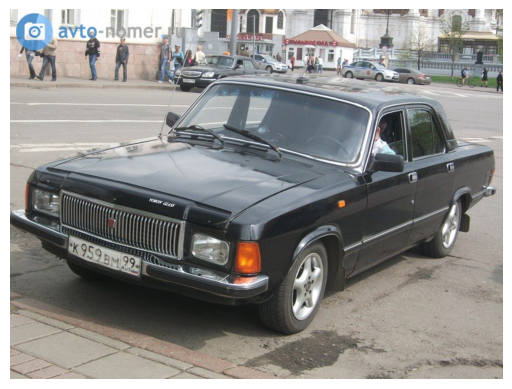

In [8]:
image = cv2.imread(train_imgs / "10.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [9]:
with open(train_mark / "10.txt", "r") as f:
    labels = f.readlines()

for label in labels:
    print(label.strip())

0 0.193125 0.668333 0.148750 0.110000


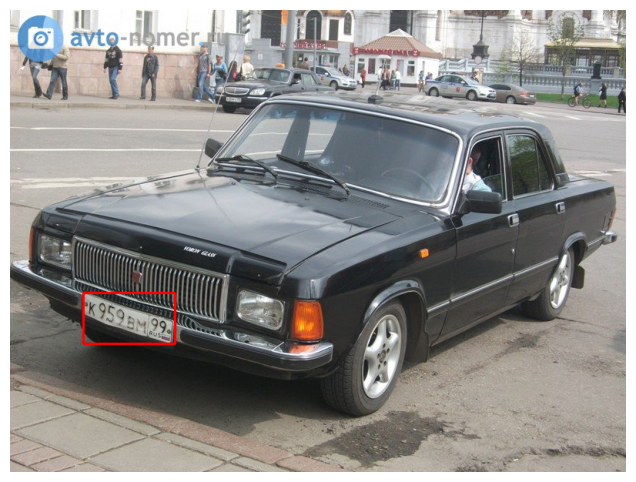

In [10]:
h, w, _ = image.shape

with open(train_mark / "10.txt", "r") as f:
    labels = f.readlines()

for label in labels:
    cls, x_center, y_center, box_w, box_h = map(float, label.split())

    x_center *= w
    y_center *= h
    box_w *= w
    box_h *= h 

    x1 = int(x_center - box_w / 2)
    y1 = int(y_center - box_h / 2)
    x2 = int(x_center + box_w / 2)
    y2 = int(y_center + box_h / 2)

    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()